# 90-Day Segment Scenario Comparison

This notebook reuses the same `XGBoost` forecast output, household system-share assumption, segment flexibility settings, and decision weights from `hourly_shift_model_v2.ipynb`.

It now benchmarks every modeled scenario against an `Actual Baseline (90d)` reference built from the realized consumption in the shared 90-day evaluation period.

The only thing that changes across scenarios is the share of household load assigned to:
- `ev`
- `thermal`
- `wet_loads`

The residual share is kept as `inflexible`.


In [8]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

ROOT = Path.cwd()
PRED_PATH = ROOT / "outputs" / "model" / "predictions.parquet"
CONSUMPTION_PATH = ROOT / "data" / "consumption_dk1_raw.csv"

HOUSEHOLD_SHARE_OF_SYSTEM = 0.33
FORECAST_HORIZON_HOURS = 120
SIMULATION_DAYS = 90
NON_OVERLAPPING_WINDOW_DAYS = 5
SIMULATION_WINDOWS = SIMULATION_DAYS // NON_OVERLAPPING_WINDOW_DAYS

ACTUAL_BASELINE_LABEL = "Actual Baseline (90d)"
CURRENT_MIX_LABEL = "Current Mix (v2)"
MODELED_SCENARIO_ORDER = [
    CURRENT_MIX_LABEL,
    "Conservative",
    "2026 Normal",
    "2035 Simulation",
]
SCENARIO_ORDER = [
    ACTUAL_BASELINE_LABEL,
    *MODELED_SCENARIO_ORDER,
]
SCENARIO_COLORS = {
    ACTUAL_BASELINE_LABEL: "#455A64",
    CURRENT_MIX_LABEL: "#546E7A",
    "Conservative": "#1E88E5",
    "2026 Normal": "#43A047",
    "2035 Simulation": "#FB8C00",
}

BASE_SEGMENT_ASSUMPTIONS = {
    "inflexible": {
        "share_of_household_load": 0.6,
        "max_shiftable_share": 0.00,
        "max_wait_h": 0,
        "wait_penalty": 0.00,
    },
    "wet_loads": {
        "share_of_household_load": 0.1,
        "max_shiftable_share": 0.35,
        "max_wait_h": 24*2,
        "wait_penalty": 0.90,
    },
    "thermal": {
        "share_of_household_load": 0.2,
        "max_shiftable_share": 0.15,
        "max_wait_h": 24*1,
        "wait_penalty": 1.20,
    },
    "ev": {
        "share_of_household_load": 0.1,
        "max_shiftable_share": 0.65,
        "max_wait_h": 24*5,
        "wait_penalty": 0.35,
    },
}

DECISION_WEIGHTS = {
    "price": 0.80,
    "wait": 0.20,
}

SCENARIO_SHARES = {
    CURRENT_MIX_LABEL: {
        "wet_loads": 0.10,
        "thermal": 0.20,
        "ev": 0.10,
    },
    "Conservative": {
        "wet_loads": 0.075,
        "thermal": 0.09,
        "ev": 0.06,
    },
    "2026 Normal": {
        "wet_loads": 0.095,
        "thermal": 0.14,
        "ev": 0.10,
    },
    "2035 Simulation": {
        "wet_loads": 0.075,
        "thermal": 0.18,
        "ev": 0.22,
    },
}


def build_segment_assumptions(shares: dict) -> dict:
    assumptions = deepcopy(BASE_SEGMENT_ASSUMPTIONS)
    for segment, share in shares.items():
        assumptions[segment]["share_of_household_load"] = float(share)

    assumptions["inflexible"]["share_of_household_load"] = 1.0 - sum(shares.values())

    total_share = sum(v["share_of_household_load"] for v in assumptions.values())
    if not np.isclose(total_share, 1.0):
        raise ValueError(f"Scenario shares must sum to 1.0, got {total_share:.6f}")

    return assumptions


In [9]:
def build_historical_segment_capacity(
    system_load: pd.DataFrame,
    segment_assumptions: dict,
) -> pd.DataFrame:
    historical_segment_capacity = system_load[["target_time", "system_load_mwh"]].copy()
    historical_segment_capacity["household_load_mwh"] = (
        historical_segment_capacity["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM
    )

    for segment, params in segment_assumptions.items():
        segment_cap_col = f"{segment}_historical_cap_mwh"
        historical_segment_capacity[segment_cap_col] = (
            historical_segment_capacity["household_load_mwh"] * params["share_of_household_load"]
        )

    historical_segment_capacity = (
        historical_segment_capacity[
            [f"{segment}_historical_cap_mwh" for segment in segment_assumptions]
        ]
        .max()
        .to_frame()
        .T
    )

    return historical_segment_capacity


def _normalize(series: pd.Series) -> pd.Series:
    s_min = float(series.min())
    s_max = float(series.max())
    if np.isclose(s_min, s_max):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)


def assemble_window_for_issue_time(
    issue_time: pd.Timestamp,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
    segment_assumptions: dict,
) -> pd.DataFrame:
    issue_time = pd.Timestamp(issue_time)
    forecast_window = (
        preds[preds["issue_time"] == issue_time]
        .sort_values("horizon_h")
        .reset_index(drop=True)
    )
    if len(forecast_window) != FORECAST_HORIZON_HOURS:
        raise ValueError(
            f"Issue time {issue_time} does not have a full {FORECAST_HORIZON_HOURS}h forecast window."
        )

    window_df = forecast_window.merge(system_load, on="target_time", how="left")
    window_df["system_load_mwh"] = window_df["system_load_mwh"].ffill().bfill()
    window_df["household_load_mwh"] = window_df["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        window_df[base_col] = window_df["household_load_mwh"] * params["share_of_household_load"]
        window_df[flex_col] = window_df[base_col] * params["max_shiftable_share"]

    return window_df


def build_actual_baseline_reference(
    issue_times: pd.Series,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
) -> pd.DataFrame:
    reference_profiles = []

    for issue_time in issue_times:
        issue_time = pd.Timestamp(issue_time)
        forecast_window = (
            preds[preds["issue_time"] == issue_time]
            .sort_values("horizon_h")
            .reset_index(drop=True)
        )
        if len(forecast_window) != FORECAST_HORIZON_HOURS:
            raise ValueError(
                f"Issue time {issue_time} does not have a full {FORECAST_HORIZON_HOURS}h forecast window."
            )

        reference_window = forecast_window[["target_time"]].merge(system_load, on="target_time", how="left")
        reference_window["system_load_mwh"] = reference_window["system_load_mwh"].ffill().bfill()
        reference_window["household_load_mwh"] = (
            reference_window["system_load_mwh"] * HOUSEHOLD_SHARE_OF_SYSTEM
        )
        reference_profiles.append(
            reference_window[["target_time", "system_load_mwh", "household_load_mwh"]]
        )

    return (
        pd.concat(reference_profiles, ignore_index=True)
        .sort_values("target_time")
        .drop_duplicates(subset=["target_time"], keep="first")
        .reset_index(drop=True)
    )


def summarize_actual_baseline(
    reference_df: pd.DataFrame,
    scenario_name: str = ACTUAL_BASELINE_LABEL,
) -> dict:
    baseline_p95 = float(reference_df["system_load_mwh"].quantile(0.95))
    baseline_hours_above_p95 = int((reference_df["system_load_mwh"] > baseline_p95).sum())
    total_system_consumption_mwh = float(reference_df["system_load_mwh"].sum())
    total_household_consumption_mwh = float(reference_df["household_load_mwh"].sum())

    return {
        "scenario": scenario_name,
        "inflexible_share_pct": np.nan,
        "wet_loads_share_pct": np.nan,
        "thermal_share_pct": np.nan,
        "ev_share_pct": np.nan,
        "simulation_hours": int(len(reference_df)),
        "simulation_days": float(len(reference_df) / 24.0),
        "simulation_start": reference_df["target_time"].min(),
        "simulation_end": reference_df["target_time"].max(),
        "shift_events": 0,
        "total_shifted_energy_mwh": 0.0,
        "modeled_total_system_consumption_mwh": total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 0.0,
        "shifted_share_of_household_consumption_pct": 0.0,
        "realized_household_savings_eur": 0.0,
        "baseline_system_load_p95_mwh": baseline_p95,
        "shifted_system_load_p95_mwh": baseline_p95,
        "baseline_hours_above_p95": baseline_hours_above_p95,
        "shifted_hours_above_p95": baseline_hours_above_p95,
        "p95_delta_mwh": 0.0,
    }


def build_shift_plan(
    window_df: pd.DataFrame,
    segment_assumptions: dict,
    decision_weights: dict,
    historical_segment_capacity: pd.DataFrame,
):
    df = window_df.copy().reset_index(drop=True)
    df["other_system_load_mwh"] = df["system_load_mwh"] - df["household_load_mwh"]

    shift_rows = []
    shifted_cols = []

    for segment, params in segment_assumptions.items():
        base_col = f"{segment}_baseline_mwh"
        flex_col = f"{segment}_flexible_mwh"
        cap_col = f"{segment}_historical_cap_mwh"
        shifted = df[base_col].to_numpy(dtype=float).copy()
        segment_capacity_value = float(historical_segment_capacity.iloc[0][cap_col])
        segment_capacity = np.full(len(df), segment_capacity_value, dtype=float)
        flexible = df[flex_col].to_numpy(dtype=float)

        if params["max_shiftable_share"] == 0 or params["max_wait_h"] == 0:
            df[f"{segment}_shifted_mwh"] = shifted
            shifted_cols.append(f"{segment}_shifted_mwh")
            continue

        for origin in range(len(df)):
            movable = flexible[origin]
            if movable <= 0:
                continue

            max_wait = int(params["max_wait_h"])
            end = min(len(df) - 1, origin + max_wait)
            candidates = df.loc[origin:end, ["target_time", "predicted"]].copy()
            candidates["wait_h"] = np.arange(len(candidates))
            candidates["price_norm"] = _normalize(candidates["predicted"])
            candidates["wait_norm"] = candidates["wait_h"] / max(max_wait, 1)

            candidates["score"] = (
                decision_weights["price"] * candidates["price_norm"]
                + decision_weights["wait"] * params["wait_penalty"] * candidates["wait_norm"]
            )

            origin_score = float(candidates.iloc[0]["score"])
            ranked_candidate_indices = candidates.sort_values("score").index.tolist()
            remaining_movable = movable

            for rank_position, candidate_idx in enumerate(ranked_candidate_indices, start=1):
                candidate_idx = int(candidate_idx)
                if candidate_idx == origin:
                    continue

                candidate_score = float(candidates.loc[candidate_idx, "score"])
                if candidate_score >= origin_score:
                    continue

                available_room = segment_capacity[candidate_idx] - shifted[candidate_idx]
                if available_room <= 0:
                    continue

                allocated_mwh = min(remaining_movable, available_room)
                if allocated_mwh <= 0:
                    continue

                score_gain = origin_score - candidate_score
                projected_target_segment_load = shifted[candidate_idx] + allocated_mwh

                shifted[origin] -= allocated_mwh
                shifted[candidate_idx] += allocated_mwh
                remaining_movable -= allocated_mwh

                shift_rows.append(
                    {
                        "segment": segment,
                        "origin_index": origin,
                        "target_index": candidate_idx,
                        "origin_time": df.loc[origin, "target_time"],
                        "target_time": df.loc[candidate_idx, "target_time"],
                        "wait_h": candidate_idx - origin,
                        "shift_mwh": allocated_mwh,
                        "origin_predicted_price": df.loc[origin, "predicted"],
                        "target_predicted_price": df.loc[candidate_idx, "predicted"],
                        "score_gain": score_gain,
                        "chosen_rank": rank_position,
                        "target_segment_capacity_mwh": segment_capacity[candidate_idx],
                        "available_room_before_allocation_mwh": available_room,
                        "projected_target_segment_load_mwh": projected_target_segment_load,
                        "remaining_origin_movable_mwh": remaining_movable,
                    }
                )

                if remaining_movable <= 1e-9:
                    break

        shifted_col = f"{segment}_shifted_mwh"
        df[shifted_col] = shifted
        shifted_cols.append(shifted_col)

    df["shifted_household_load_mwh"] = df[shifted_cols].sum(axis=1)
    df["shifted_system_load_mwh"] = df["other_system_load_mwh"] + df["shifted_household_load_mwh"]
    df["baseline_household_cost_eur"] = df["household_load_mwh"] * df["DayAheadPriceEUR"]
    df["shifted_household_cost_eur"] = df["shifted_household_load_mwh"] * df["DayAheadPriceEUR"]

    shifts = pd.DataFrame(
        shift_rows,
        columns=[
            "segment",
            "origin_index",
            "target_index",
            "origin_time",
            "target_time",
            "wait_h",
            "shift_mwh",
            "origin_predicted_price",
            "target_predicted_price",
            "score_gain",
            "chosen_rank",
            "target_segment_capacity_mwh",
            "available_room_before_allocation_mwh",
            "projected_target_segment_load_mwh",
            "remaining_origin_movable_mwh",
        ],
    )

    return df, shifts


def run_scenario(
    scenario_name: str,
    scenario_shares: dict,
    issue_times: pd.Series,
    preds: pd.DataFrame,
    system_load: pd.DataFrame,
    baseline_reference_p95_mwh: float,
) -> dict:
    segment_assumptions = build_segment_assumptions(scenario_shares)
    historical_segment_capacity = build_historical_segment_capacity(
        system_load=system_load,
        segment_assumptions=segment_assumptions,
    )

    scenario_profiles = []
    total_shifted_energy_mwh = 0.0
    total_shift_events = 0

    for issue_time in issue_times:
        window_df = assemble_window_for_issue_time(
            issue_time=issue_time,
            preds=preds,
            system_load=system_load,
            segment_assumptions=segment_assumptions,
        )
        profile_df, shifts_df = build_shift_plan(
            window_df=window_df,
            segment_assumptions=segment_assumptions,
            decision_weights=DECISION_WEIGHTS,
            historical_segment_capacity=historical_segment_capacity,
        )
        profile_df = profile_df.copy()
        profile_df["scenario"] = scenario_name
        profile_df["issue_time"] = pd.Timestamp(issue_time)
        scenario_profiles.append(profile_df)

        if not shifts_df.empty:
            total_shifted_energy_mwh += float(shifts_df["shift_mwh"].sum())
            total_shift_events += int(len(shifts_df))

    scenario_profiles_df = (
        pd.concat(scenario_profiles, ignore_index=True)
        .sort_values("target_time")
        .drop_duplicates(subset=["target_time"], keep="first")
        .reset_index(drop=True)
    )

    baseline_p95 = float(baseline_reference_p95_mwh)
    shifted_p95 = float(scenario_profiles_df["shifted_system_load_mwh"].quantile(0.95))
    baseline_hours_above_p95 = int((scenario_profiles_df["system_load_mwh"] > baseline_p95).sum())
    shifted_hours_above_p95 = int((scenario_profiles_df["shifted_system_load_mwh"] > baseline_p95).sum())
    total_system_consumption_mwh = float(scenario_profiles_df["system_load_mwh"].sum())
    total_household_consumption_mwh = float(scenario_profiles_df["household_load_mwh"].sum())

    return {
        "scenario": scenario_name,
        "inflexible_share_pct": 100.0 * segment_assumptions["inflexible"]["share_of_household_load"],
        "wet_loads_share_pct": 100.0 * segment_assumptions["wet_loads"]["share_of_household_load"],
        "thermal_share_pct": 100.0 * segment_assumptions["thermal"]["share_of_household_load"],
        "ev_share_pct": 100.0 * segment_assumptions["ev"]["share_of_household_load"],
        "simulation_hours": int(len(scenario_profiles_df)),
        "simulation_days": float(len(scenario_profiles_df) / 24.0),
        "simulation_start": scenario_profiles_df["target_time"].min(),
        "simulation_end": scenario_profiles_df["target_time"].max(),
        "shift_events": total_shift_events,
        "total_shifted_energy_mwh": total_shifted_energy_mwh,
        "modeled_total_system_consumption_mwh": total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 100.0 * total_shifted_energy_mwh / total_system_consumption_mwh,
        "shifted_share_of_household_consumption_pct": 100.0 * total_shifted_energy_mwh / total_household_consumption_mwh,
        "realized_household_savings_eur": float(
            scenario_profiles_df["baseline_household_cost_eur"].sum()
            - scenario_profiles_df["shifted_household_cost_eur"].sum()
        ),
        "baseline_system_load_p95_mwh": baseline_p95,
        "shifted_system_load_p95_mwh": shifted_p95,
        "baseline_hours_above_p95": baseline_hours_above_p95,
        "shifted_hours_above_p95": shifted_hours_above_p95,
        "p95_delta_mwh": shifted_p95 - baseline_p95,
    }


In [10]:
preds = pd.read_parquet(PRED_PATH)
preds["issue_time"] = pd.to_datetime(preds["issue_time"])
preds["target_time"] = pd.to_datetime(preds["target_time"])
preds["fold_end"] = pd.to_datetime(preds["fold_end"])
preds = preds.sort_values(["fold", "issue_time", "horizon_h"]).reset_index(drop=True)

coverage = (
    preds.groupby(["fold", "issue_time"], as_index=False)
    .agg(
        horizons=("horizon_h", "nunique"),
        min_h=("horizon_h", "min"),
        max_h=("horizon_h", "max"),
    )
)
full_coverage = coverage[
    (coverage["horizons"] == FORECAST_HORIZON_HOURS)
    & (coverage["min_h"] == 1)
    & (coverage["max_h"] == FORECAST_HORIZON_HOURS)
].copy()
issue_catalog = full_coverage.sort_values("issue_time").reset_index(drop=True)
daily_issue_times = issue_catalog.loc[
    issue_catalog["issue_time"].dt.hour == 12,
    "issue_time",
].reset_index(drop=True)

consumption = pd.read_csv(CONSUMPTION_PATH, parse_dates=["TimeDK"])
system_load = (
    consumption.groupby(pd.Grouper(key="TimeDK", freq="h"))["ConsumptionkWh"]
    .sum()
    .div(1000.0)
    .rename("system_load_mwh")
    .reset_index()
    .rename(columns={"TimeDK": "target_time"})
)

scenario_share_rows = []
for scenario_name in MODELED_SCENARIO_ORDER:
    assumptions = build_segment_assumptions(SCENARIO_SHARES[scenario_name])
    scenario_share_rows.append(
        {
            "scenario": scenario_name,
            "inflexible_share_pct": 100.0 * assumptions["inflexible"]["share_of_household_load"],
            "wet_loads_share_pct": 100.0 * assumptions["wet_loads"]["share_of_household_load"],
            "thermal_share_pct": 100.0 * assumptions["thermal"]["share_of_household_load"],
            "ev_share_pct": 100.0 * assumptions["ev"]["share_of_household_load"],
        }
    )

scenario_share_table = pd.DataFrame(scenario_share_rows).set_index("scenario")
display(scenario_share_table.round(1))


,inflexible_share_pct,wet_loads_share_pct,thermal_share_pct,ev_share_pct
scenario,,,,
Current Mix (v2),60.0,10.0,20.0,10.0
Conservative,77.5,7.5,9.0,6.0
2026 Normal,66.5,9.5,14.0,10.0
2035 Simulation,52.5,7.5,18.0,22.0


In [11]:
simulation_daily_issue_times = daily_issue_times.tail(SIMULATION_DAYS).reset_index(drop=True)
simulation_issue_times = simulation_daily_issue_times.iloc[::NON_OVERLAPPING_WINDOW_DAYS].reset_index(drop=True)

if len(simulation_issue_times) != SIMULATION_WINDOWS:
    raise ValueError(
        f"Expected {SIMULATION_WINDOWS} non-overlapping windows for {SIMULATION_DAYS} days, "
        f"but found {len(simulation_issue_times)}."
    )

simulation_window_summary = pd.Series(
    {
        "available_full_120h_issue_times": int(len(issue_catalog)),
        "available_daily_noon_issue_times": int(len(daily_issue_times)),
        "simulation_days": SIMULATION_DAYS,
        "non_overlapping_window_days": NON_OVERLAPPING_WINDOW_DAYS,
        "simulation_windows": int(len(simulation_issue_times)),
        "simulated_hours": int(len(simulation_issue_times) * FORECAST_HORIZON_HOURS),
        "first_issue_time": str(simulation_issue_times.iloc[0]),
        "last_issue_time": str(simulation_issue_times.iloc[-1]),
    }
)

display(simulation_window_summary.to_frame("value"))


,value
available_full_120h_issue_times,2162
available_daily_noon_issue_times,1081
simulation_days,90
non_overlapping_window_days,5
simulation_windows,18
simulated_hours,2160
first_issue_time,2025-10-03 12:00:00
last_issue_time,2025-12-27 12:00:00


In [12]:
actual_baseline_df = build_actual_baseline_reference(
    issue_times=simulation_issue_times,
    preds=preds,
    system_load=system_load,
)
actual_baseline_result = summarize_actual_baseline(actual_baseline_df)
actual_baseline_p95 = float(actual_baseline_result["baseline_system_load_p95_mwh"])

scenario_results = [actual_baseline_result] + [
    run_scenario(
        scenario_name=scenario_name,
        scenario_shares=SCENARIO_SHARES[scenario_name],
        issue_times=simulation_issue_times,
        preds=preds,
        system_load=system_load,
        baseline_reference_p95_mwh=actual_baseline_p95,
    )
    for scenario_name in MODELED_SCENARIO_ORDER
]

results_df = pd.DataFrame(scenario_results)
results_df = (
    results_df.set_index("scenario")
    .loc[SCENARIO_ORDER]
    .reset_index()
)

actual_baseline_shifted_energy = float(
    results_df.loc[
        results_df["scenario"] == ACTUAL_BASELINE_LABEL,
        "total_shifted_energy_mwh",
    ].iloc[0]
)
actual_baseline_p95 = float(
    results_df.loc[
        results_df["scenario"] == ACTUAL_BASELINE_LABEL,
        "shifted_system_load_p95_mwh",
    ].iloc[0]
)
actual_baseline_hours_above_p95 = int(
    results_df.loc[
        results_df["scenario"] == ACTUAL_BASELINE_LABEL,
        "shifted_hours_above_p95",
    ].iloc[0]
)

results_df["delta_vs_actual_baseline_shifted_energy_mwh"] = (
    results_df["total_shifted_energy_mwh"] - actual_baseline_shifted_energy
)
results_df["delta_vs_actual_baseline_p95_mwh"] = (
    results_df["shifted_system_load_p95_mwh"] - actual_baseline_p95
)
results_df["delta_vs_actual_baseline_hours_above_p95"] = (
    results_df["shifted_hours_above_p95"] - actual_baseline_hours_above_p95
)

display(
    results_df[
        [
            "scenario",
            "simulation_days",
            "shift_events",
            "total_shifted_energy_mwh",
            "shifted_share_of_system_consumption_pct",
            "shifted_share_of_household_consumption_pct",
            "baseline_system_load_p95_mwh",
            "shifted_system_load_p95_mwh",
            "delta_vs_actual_baseline_p95_mwh",
            "realized_household_savings_eur",
        ]
    ].round(2)
)


,scenario,simulation_days,shift_events,total_shifted_energy_mwh,shifted_share_of_system_consumption_pct,shifted_share_of_household_consumption_pct,baseline_system_load_p95_mwh,shifted_system_load_p95_mwh,delta_vs_actual_baseline_p95_mwh,realized_household_savings_eur
0,Actual Baseline (90d),90.0,0,0.00,0.00,0.00,3367.89,3367.89,0.00,0.00
1,Current Mix (v2),90.0,5996,146945.90,2.40,7.28,3367.89,3359.12,-8.77,3954525.10
2,Conservative,90.0,5996,87899.89,1.44,4.35,3367.89,3351.17,-16.72,2366082.24
3,2026 Normal,90.0,5996,131484.87,2.15,6.51,3367.89,3351.05,-16.84,3512630.44
4,2035 Simulation,90.0,5996,203687.74,3.33,10.09,3367.89,3382.14,14.25,5274671.34


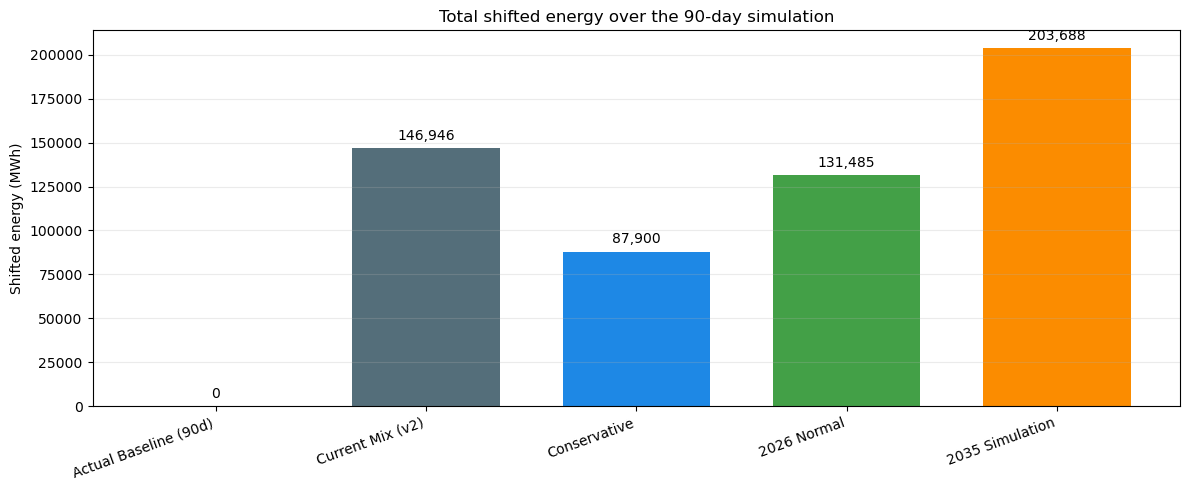

In [13]:
plot_df = results_df.copy()
bar_colors = [SCENARIO_COLORS[scenario] for scenario in plot_df["scenario"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    plot_df["scenario"],
    plot_df["total_shifted_energy_mwh"],
    color=bar_colors,
    width=0.7,
)

ax.set_title("Total shifted energy over the 90-day simulation")
ax.set_ylabel("Shifted energy (MWh)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)

ymax = float(plot_df["total_shifted_energy_mwh"].max())
for bar, value in zip(bars, plot_df["total_shifted_energy_mwh"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ymax * 0.015,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()


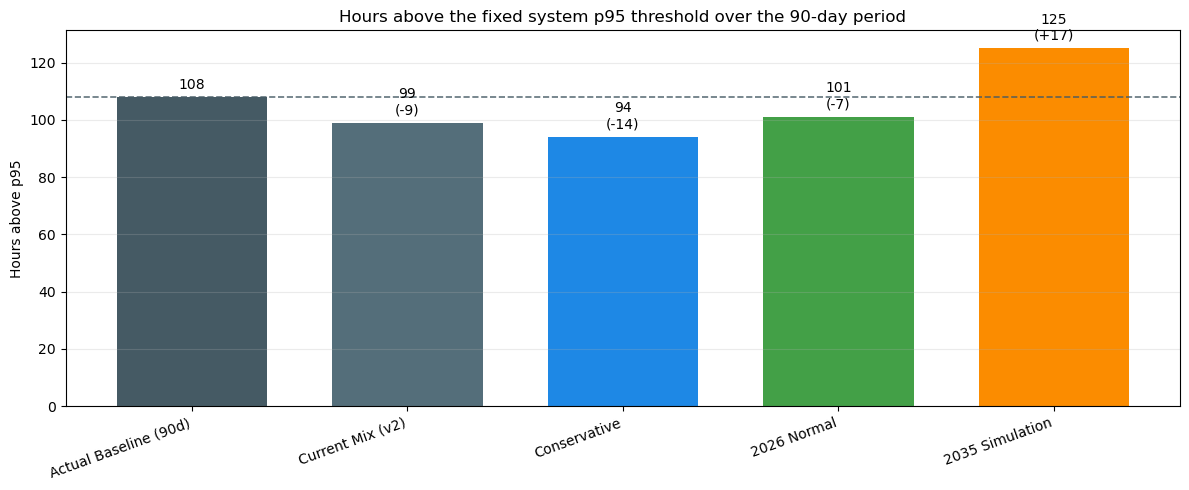

In [14]:
plot_df = results_df.copy()
bar_colors = [SCENARIO_COLORS[scenario] for scenario in plot_df["scenario"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    plot_df["scenario"],
    plot_df["shifted_hours_above_p95"],
    color=bar_colors,
    width=0.7,
)

ax.axhline(
    actual_baseline_hours_above_p95,
    color=SCENARIO_COLORS[ACTUAL_BASELINE_LABEL],
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
)

ax.set_title("Hours above the fixed system p95 threshold over the 90-day period")
ax.set_ylabel("Hours above p95")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)

ymax = float(plot_df["shifted_hours_above_p95"].max())
for bar, scenario_name, value, delta in zip(
    bars,
    plot_df["scenario"],
    plot_df["shifted_hours_above_p95"],
    plot_df["delta_vs_actual_baseline_hours_above_p95"],
):
    label = f"{int(value):,}" if scenario_name == ACTUAL_BASELINE_LABEL else f"{int(value):,}\n({int(delta):+d})"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(ymax * 0.015, 1.0),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
